In [1]:
import btwxt
import numpy as np
import pandas as pd

In [2]:
# EIR F(LWT, T_OA_DB)
x_lwts = np.array([30, 35, 40, 45, 50, 55])
x_oat_dbs = np.array([-20, -15, -7, -2, 2, 7, 12, 15, 20])
ys = np.array([0.38910506, 0.35460993, 0.29761905, 0.26595745, 0.24154589, 0.21459227, 0.18975332,
        0.1754386,  0.155521,   0.42553191, 0.38910506, 0.330033,   0.29761905, 0.27027027,
        0.23923445, 0.21276596, 0.1980198,  0.17513135, 0.46948357, 0.42918455, 0.36900369,
        0.33222591, 0.30395137, 0.27027027, 0.24096386, 0.22371365, 0.1984127,  1.,
        1.,         0.41493776, 0.37593985, 0.34246575, 0.30674847, 0.27247956, 0.25380711,
        0.22573363, 1.,         1.,         1.,         0.42194093, 0.390625,   0.34843206,
        0.31055901, 0.28901734, 0.25641026, 1.,         1.,         1.,         1.,
        0.45045045, 0.40322581, 0.35971223, 0.34602076, 0.30864198])

df_ori = pd.DataFrame(ys.reshape(x_lwts.size, x_oat_dbs.size), index=x_lwts, columns=x_oat_dbs).T
df_ori.index.name = 'OAT db (C)'
df_ori.index = df_ori.index.astype(int)
df_ori.columns.name = 'LWT (K)'
df_ori.columns = df_ori.columns.astype(int)
df_ori

LWT (K),30,35,40,45,50,55
OAT db (C),,,,,,
-20,0.389105,0.425532,0.469484,1.000000,1.000000,1.000000
-15,0.354610,0.389105,0.429185,1.000000,1.000000,1.000000
-7,0.297619,0.330033,0.369004,0.414938,1.000000,1.000000
-2,0.265957,0.297619,0.332226,0.375940,0.421941,1.000000
2,0.241546,0.270270,0.303951,0.342466,0.390625,0.450450
7,0.214592,0.239234,0.270270,0.306748,0.348432,0.403226
12,0.189753,0.212766,0.240964,0.272480,0.310559,0.359712
15,0.175439,0.198020,0.223714,0.253807,0.289017,0.346021
20,0.155521,0.175131,0.198413,0.225734,0.256410,0.308642


In [3]:
x_lwt = btwxt.GridAxis(
    x_lwts.tolist(), # Values
    btwxt.InterpolationMethod_cubic, # interpolation method
    btwxt.ExtrapolationMethod_linear, # extrapolation_method
    (-float(np.inf), float(np.inf)), # extrapolation_limits,
    "LWT", # name
)

In [4]:
x_oat_db = btwxt.GridAxis(
    x_oat_dbs.tolist(), # Values
    btwxt.InterpolationMethod_cubic, # interpolation method
    btwxt.ExtrapolationMethod_linear, # extrapolation_method
    (-float(np.inf), float(np.inf)), # extrapolation_limits
    "OAT_db", # name
)

In [5]:
grid_point_y = btwxt.GridPointDataSet(ys, "EIRFT")

In [6]:
interpolator = btwxt.RegularGridInterpolator([x_lwt, x_oat_db], [grid_point_y])

In [7]:
RATED_LWT_C = 35.0
RATED_OAT_DB_C = 7.0

In [8]:
target_normalization = [RATED_LWT_C, RATED_OAT_DB_C]

In [9]:
normalizationDivisor = 1.0 # This is the Table:Lookup global normalization divisor
normalizationDivisor = interpolator.normalize_grid_point_data_set_at_target(
    0, target_normalization, normalizationDivisor
) * normalizationDivisor
normalizationDivisor

0.23923445

In [10]:
interp_lwts = np.arange(25.0, 60.1, 1.0)
interp_oat_dbs = np.arange(-25.0, 25.1, 1.0)

ut, vt = np.meshgrid(interp_lwts, interp_oat_dbs, indexing='ij')
test_points = np.array([ut.ravel(), vt.ravel()]).T

vals = np.apply_along_axis(
    func1d=lambda x: interpolator.get_value_at_target([x[0], x[1]], 0), 
    axis=1,
    arr=test_points
)

df_interp = pd.DataFrame(vals.reshape(interp_lwts.size, interp_oat_dbs.size), index=interp_lwts, columns=interp_oat_dbs).T
df_interp.index.name = 'OAT db (C)'
df_interp.index = df_interp.index.astype(int)
df_interp.columns.name = 'LWT (K)'
df_interp.columns = df_interp.columns.astype(int)
df_interp = df_interp * normalizationDivisor

In [11]:
df_interp.reindex_like(df_ori) - df_ori

LWT (K),30,35,40,45,50,55
OAT db (C),,,,,,
-20,0.000000e+00,5.551115e-17,0.000000e+00,0.000000e+00,0.0,0.0
-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
-7,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
-2,0.000000e+00,0.000000e+00,5.551115e-17,0.000000e+00,0.0,0.0
2,2.775558e-17,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
7,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0
15,0.000000e+00,0.000000e+00,0.000000e+00,5.551115e-17,0.0,0.0
20,0.000000e+00,0.000000e+00,2.775558e-17,0.000000e+00,0.0,0.0


# Plot

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='LWT (K)', ylabel='OAT db (C)'>

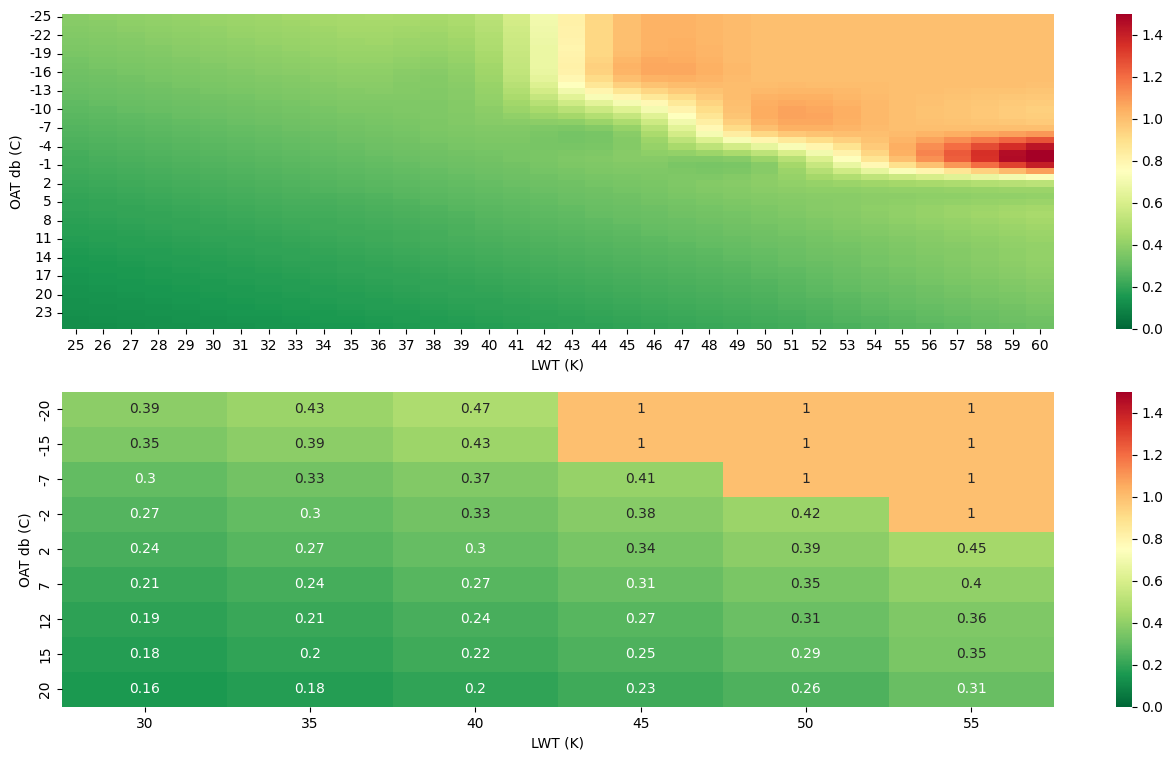

In [13]:
fig, ax = plt.subplots(figsize=(16, 9), nrows=2)
sns.heatmap(df_interp, ax=ax[0], vmin=0, vmax=1.5, cmap='RdYlGn_r')
sns.heatmap(df_ori, ax=ax[1], vmin=0, vmax=1.5, cmap='RdYlGn_r', annot=True)